# Conditional Coverage — Nadir Imaging with Ground-Station Tracking

Demonstrates the **conditions** feature in missiontools.

The spacecraft normally images in nadir-pointing mode, but when it comes
within view of a ground station it stops imaging and reorients to track
the station with its body X+ face (e.g. for a downlink antenna).

This is implemented using:

- **`ConditionAttitudeLaw`** — routes between two attitude laws based on
  a `SpaceGroundAccessCondition`
- **Sensor `condition`** — a `NotCondition` that disables the sensor when
  the ground station is in view

**Scenario**
- 550 km sun-synchronous orbit, LTAN 10:30
- Nadir-pointed conic sensor, 15° half-angle (active only when GS is *not* visible)
- Ground station: Svalbard (78.2°N, 15.6°E), el_min_deg = 5°
- Area of interest: Svalbard region
- Analysis window: 10 days

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from missiontools import (
    Spacecraft, ConicSensor, AoI, Coverage, GroundStation,
    FixedAttitudeLaw, TrackAttitudeLaw, ConditionAttitudeLaw,
    SpaceGroundAccessCondition, NotCondition,
)

## 1. Spacecraft and Ground Station

In [2]:
EPOCH = np.datetime64('2025-06-01T00:00:00', 'us')

sc = Spacecraft.sunsync(
    altitude_km=550.0,
    node_solar_time='10:30',
    epoch=EPOCH,
)

gs = GroundStation(lat=78.2, lon=15.6)

period_s = 2 * np.pi * np.sqrt(sc.a**3 / sc.central_body_mu)
print(f"Altitude       : {(sc.a - sc.central_body_radius) / 1e3:.0f} km")
print(f"Inclination    : {np.degrees(sc.i):.2f}°")
print(f"Orbital period : {period_s / 60:.1f} min")
print(f"Ground station : Svalbard ({gs.lat}°N, {gs.lon}°E)")

Altitude       : 550 km
Inclination    : 97.59°
Orbital period : 95.6 min
Ground station : Svalbard (78.2°N, 15.6°E)


## 2. Conditional Attitude Law

The attitude law selects between two modes:

1. **Default (nadir)**: `FixedAttitudeLaw.nadir()` — body-z points at
   Earth centre; used when the spacecraft is *not* in view of Svalbard.
2. **GS tracking**: `TrackAttitudeLaw(gs)` — body-z points at the ground
   station; used when `SpaceGroundAccessCondition` is true.

In a real mission, the tracking law would orient the body-X face (where
the downlink antenna is mounted) toward the station. Here we use
`TrackAttitudeLaw` to point body-z at the station, which demonstrates
the mechanism clearly.

In [3]:
nadir_law = FixedAttitudeLaw.nadir()
track_law = TrackAttitudeLaw(gs)

gs_visible = SpaceGroundAccessCondition(sc, gs, el_min_deg=5.0)

attitude_law = ConditionAttitudeLaw(
    default_attitude=nadir_law,
    condition_attitudes=[(gs_visible, track_law)],
)

sc.attitude_law = attitude_law

print(f"Attitude law : {attitude_law}")

Attitude law : ConditionAttitudeLaw(default=FixedAttitudeLaw(frame='lvlh', boresight=[-1.  0.  0.]), branches=[(SpaceGroundAccessCondition(spacecraft=Spacecraft(a=6928137.0, e=0.0, i=1.7033142931462117, raan=0.8148686612074731, arg_p=0.0, ma=np.float64(0.0), epoch=datetime.datetime(2025, 6, 1, 0, 0), propagator_type='j2', central_body_mu=398600441800000.0, central_body_j2=1.75553e+25, central_body_radius=6378137.0), ground_station=GroundStation(lat=78.2, lon=15.6, alt=0.0), el_min_deg=5.0), TrackAttitudeLaw(target=GroundStation(lat=78.2, lon=15.6, alt=0.0)))])


## 3. Sensor with Conditional Activation

The sensor is a 15° half-angle conic sensor pointing along body-z
(nadir when in default mode). It carries a `NotCondition` wrapping the
same ground-station visibility predicate, so it only collects imagery
when the spacecraft is *not* tracking the ground station.

In [4]:
sensor = ConicSensor(
    15.0,
    body_vector=[0, 0, 1],
    condition=~gs_visible,
)
sc.add_sensor(sensor)

print(f"Sensor          : {sensor}")
print(f"Sensor condition: {sensor.condition}")

Sensor          : ConicSensor(half_angle_deg=15.000, mode='body', body_vector=[0.0, 0.0, 1.0], condition=NotCondition(SpaceGroundAccessCondition(spacecraft=Spacecraft(a=6928137.0, e=0.0, i=1.7033142931462117, raan=0.8148686612074731, arg_p=0.0, ma=np.float64(0.0), epoch=datetime.datetime(2025, 6, 1, 0, 0), propagator_type='j2', central_body_mu=398600441800000.0, central_body_j2=1.75553e+25, central_body_radius=6378137.0), ground_station=GroundStation(lat=78.2, lon=15.6, alt=0.0), el_min_deg=5.0)))
Sensor condition: NotCondition(SpaceGroundAccessCondition(spacecraft=Spacecraft(a=6928137.0, e=0.0, i=1.7033142931462117, raan=0.8148686612074731, arg_p=0.0, ma=np.float64(0.0), epoch=datetime.datetime(2025, 6, 1, 0, 0), propagator_type='j2', central_body_mu=398600441800000.0, central_body_j2=1.75553e+25, central_body_radius=6378137.0), ground_station=GroundStation(lat=78.2, lon=15.6, alt=0.0), el_min=5.0))


## 4. Area of Interest and Coverage Setup

We use a region around Svalbard and a 10-day analysis window.

In [5]:
aoi = AoI.from_region(
    lat_min_deg=75.0, lat_max_deg=81.0,
    lon_min_deg=10.0, lon_max_deg=35.0,
    point_density=5_000,
)

T_START = EPOCH
T_END   = EPOCH + np.timedelta64(10 * 86_400, 's')

cov = Coverage(aoi, [sensor], el_min_deg=10.0)

print(f"AoI points : {len(aoi)}")
print(f"Window     : 10 days")

AoI points : 99
Window     : 10 days


## 5. Coverage Results

In [6]:
print("Computing coverage fraction ...")
frac = cov.coverage_fraction(T_START, T_END, max_step=np.timedelta64(10, 's'))
print(f"  Final cumulative coverage : {frac['final_cumulative']:.1%}")
print(f"  Mean instantaneous        : {frac['mean_fraction']:.1%}")

print("\nComputing revisit times ...")
rev = cov.revisit_time(T_START, T_END, max_step=np.timedelta64(10, 's'))
global_mean_hrs = rev['global_mean'] / 3600.0
global_max_hrs  = rev['global_max']  / 3600.0
print(f"  Global mean revisit : {global_mean_hrs:.1f} h")
print(f"  Global max revisit  : {global_max_hrs:.1f} h")

Computing coverage fraction ...


  Final cumulative coverage : 0.0%
  Mean instantaneous        : 0.0%

Computing revisit times ...


  Global mean revisit : nan h
  Global max revisit  : nan h


## 6. Ground-Station Access Intervals

Show when the ground station is visible, which are the intervals where
imaging is suspended and the spacecraft tracks the station.

In [7]:
passes = gs.access(sc, T_START, T_END, el_min_deg=5.0)

print(f"Ground-station passes over 10 days: {len(passes)}")
print()
for i, (t0, t1) in enumerate(passes[:10]):
    dur_min = (t1 - t0) / np.timedelta64(60, 's')
    print(f"  Pass {i+1:>2}: {str(t0)[:19]} — {str(t1)[:19]}  ({dur_min:.1f} min)")
if len(passes) > 10:
    print(f"  ... and {len(passes) - 10} more passes")

Ground-station passes over 10 days: 134

  Pass  1: 2025-06-01T01:10:57 — 2025-06-01T01:18:14  (7.3 min)
  Pass  2: 2025-06-01T02:46:04 — 2025-06-01T02:55:05  (9.0 min)
  Pass  3: 2025-06-01T04:21:07 — 2025-06-01T04:30:56  (9.8 min)
  Pass  4: 2025-06-01T05:56:00 — 2025-06-01T06:05:57  (9.9 min)
  Pass  5: 2025-06-01T07:30:42 — 2025-06-01T07:40:28  (9.8 min)
  Pass  6: 2025-06-01T09:05:09 — 2025-06-01T09:14:48  (9.7 min)
  Pass  7: 2025-06-01T10:39:30 — 2025-06-01T10:49:15  (9.8 min)
  Pass  8: 2025-06-01T12:14:00 — 2025-06-01T12:23:57  (9.9 min)
  Pass  9: 2025-06-01T13:49:03 — 2025-06-01T13:58:51  (9.8 min)
  Pass 10: 2025-06-01T15:24:55 — 2025-06-01T15:33:54  (9.0 min)
  ... and 124 more passes


## 7. Attitude Mode Timeline

Plot the GS visibility condition over the first 3 orbits to visualise
when the spacecraft switches between imaging and tracking modes.

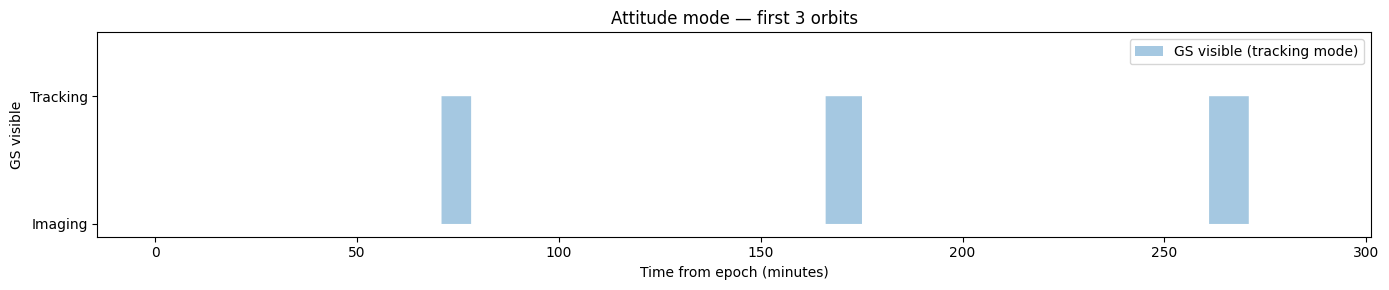

In [8]:
t_first3 = T_START + np.arange(
    0, 3 * period_s, 10,
).astype('timedelta64[s]')
t_rel_min = (t_first3 - T_START) / np.timedelta64(60, 's')

vis = gs_visible.at(t_first3).astype(float)

fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(t_rel_min, vis, step='mid', alpha=0.4,
                label='GS visible (tracking mode)')
ax.set_ylabel('GS visible')
ax.set_xlabel('Time from epoch (minutes)')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Imaging', 'Tracking'])
ax.set_ylim(-0.1, 1.5)
ax.set_title('Attitude mode — first 3 orbits')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 8. Summary

In [9]:
print("=" * 60)
print("10-day conditional coverage — Svalbard region")
print("550 km SSO LTAN 10:30 | 15° sensor | Svalbard GS (78.2°N)")
print("=" * 60)
print(f"Cumulative coverage fraction : {frac['final_cumulative']:.1%}")
print(f"Mean instantaneous coverage  : {frac['mean_fraction']:.1%}")
print(f"Global mean revisit time     : {global_mean_hrs:.1f} h")
print(f"Global max revisit time      : {global_max_hrs:.1f} h")
print(f"Ground-station passes        : {len(passes)}")
total_track_min = sum((t1 - t0) / np.timedelta64(60, 's') for t0, t1 in passes)
print(f"Total tracking time          : {total_track_min:.0f} min ({total_track_min / 60:.1f} h)")
print(f"Tracking duty cycle          : {total_track_min / (10 * 1440):.2%}")
print("=" * 60)

10-day conditional coverage — Svalbard region
550 km SSO LTAN 10:30 | 15° sensor | Svalbard GS (78.2°N)
Cumulative coverage fraction : 0.0%
Mean instantaneous coverage  : 0.0%
Global mean revisit time     : nan h
Global max revisit time      : nan h
Ground-station passes        : 134
Total tracking time          : 1105 min (18.4 h)
Tracking duty cycle          : 7.67%
